# 05. 非線形ダイナミクス — 捕食者・被食者・感染・分岐・カオス

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. Lotka-Volterra 〜 8. カオス |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

非線形 ODE は、線形系にはない豊かな現象——**周期軌道・分岐・カオス**——を生みます。
本章は代表的な非線形モデルを通して、その入口を体験します。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting, datasets

## 5. Lotka-Volterra — 捕食者と被食者 (Applied)

$$
\dot{x} = \alpha x - \beta x y, \qquad \dot{y} = \delta x y - \gamma y
$$

被食者 $x$ と捕食者 $y$ は互いに増減を引き起こし、**閉じた周期軌道** を描きます(個体数が周期的に振動)。

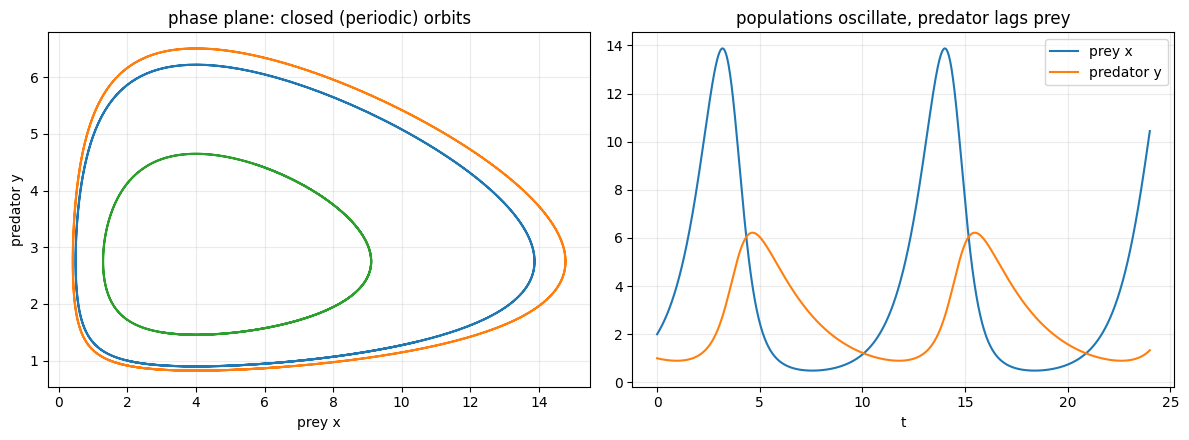

In [3]:
import numpy as np

# Predator-prey: closed orbits in phase space + oscillating populations in time.
sc = datasets.lotka_volterra_scenario()
f = systems.lotka_volterra(**sc.params)
Y = solvers.rk4(f, sc.y0, sc.t)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for y0 in ([2, 1], [1.5, 1], [3, 1.5]):
    traj = solvers.rk4(f, y0, sc.t)
    a1.plot(traj[:, 0], traj[:, 1], lw=1.5)
a1.set_xlabel("prey x")
a1.set_ylabel("predator y")
a1.set_title("phase plane: closed (periodic) orbits")
a1.grid(alpha=0.25)
a2.plot(sc.t, Y[:, 0], label="prey x")
a2.plot(sc.t, Y[:, 1], label="predator y")
a2.legend()
a2.grid(alpha=0.25)
a2.set_xlabel("t")
a2.set_title("populations oscillate, predator lags prey")
fig.tight_layout()
plt.show()

## 6. SIR — 感染症の流行

$$
\dot{S} = -\beta S I,\quad \dot{I} = \beta S I - \gamma I,\quad \dot{R} = \gamma I
$$

基本再生産数 $R_0 = \beta/\gamma$。$R_0 > 1$ なら感染は一度拡大してピークを作り、やがて終息します。

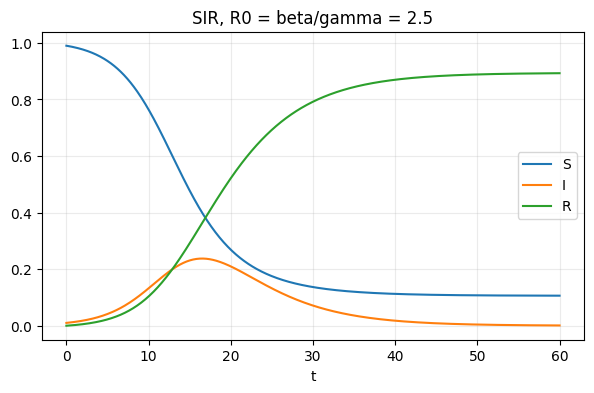

peak infected fraction = 0.238


In [4]:
# SIR outbreak: susceptible / infected / recovered over time.
sc = datasets.sir_scenario()
f = systems.sir(**sc.params)
Y = solvers.rk4(f, sc.y0, sc.t)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sc.t, Y[:, 0], label="S")
ax.plot(sc.t, Y[:, 1], label="I")
ax.plot(sc.t, Y[:, 2], label="R")
ax.legend()
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title(f"SIR, R0 = beta/gamma = {sc.params['beta'] / sc.params['gamma']:.1f}")
plt.show()
print("peak infected fraction =", round(float(Y[:, 1].max()), 3))

## 7. 分岐 (bifurcation) — パラメータで質が変わる

パラメータをゆっくり変えると、固定点の **数や安定性が突然変わる** ことがあります。
$\dot{y} = r y - y^3$ の平衡点は、$r<0$ では $y=0$ のみ(安定)、$r>0$ で $y=\pm\sqrt{r}$ が現れる
**ピッチフォーク分岐** です。

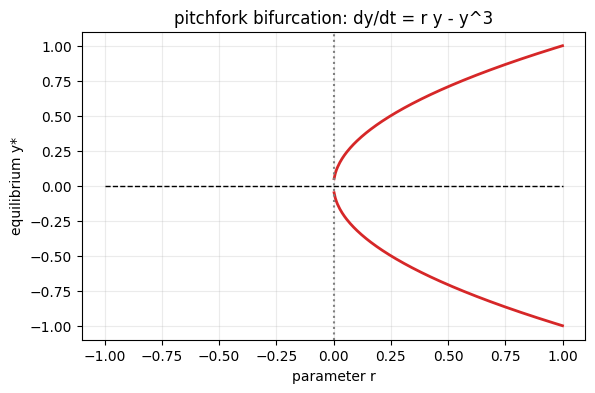

In [5]:
import numpy as np

# Pitchfork bifurcation of dy/dt = r y - y^3: equilibria branch at r=0.
r = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(r, np.zeros_like(r), "k--", lw=1)  # y=0 (dashed=unstable for r>0)
ax.plot(r[r >= 0], np.sqrt(r[r >= 0]), color="#d62728", lw=2)
ax.plot(r[r >= 0], -np.sqrt(r[r >= 0]), color="#d62728", lw=2)
ax.axvline(0, color="gray", ls=":")
ax.set_xlabel("parameter r")
ax.set_ylabel("equilibrium y*")
ax.set_title("pitchfork bifurcation: dy/dt = r y - y^3")
ax.grid(alpha=0.25)
plt.show()

## 8. カオスの入口 — Lorenz 系 (Advanced)

平面ではカオスは起きません(Poincaré–Bendixson)。3 次元になると話が変わります。**Lorenz 系**

$$
\dot{x} = \sigma(y-x),\quad \dot{y} = x(\rho - z) - y,\quad \dot{z} = xy - \beta z
$$

は有名な蝶形アトラクタを描き、**初期値鋭敏性**(わずかな差が指数的に拡大)を示します。

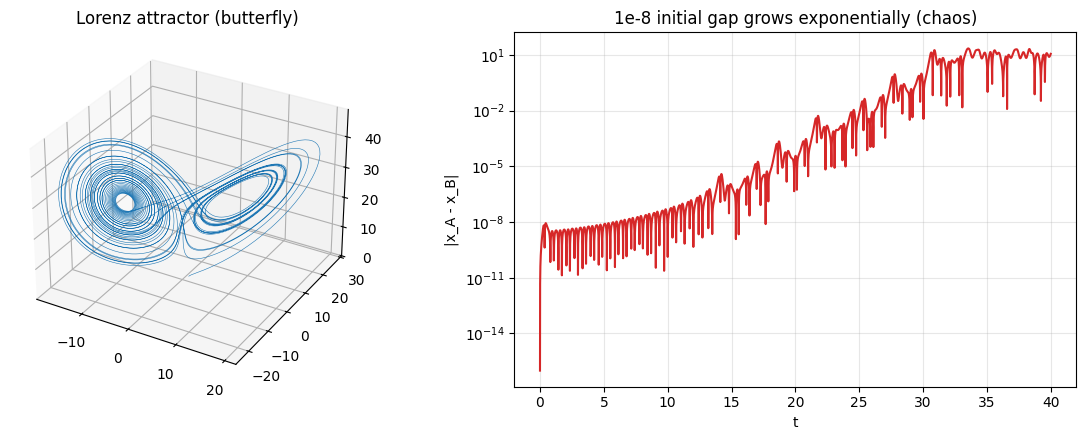

In [6]:
import numpy as np

# Lorenz attractor + sensitive dependence on initial conditions.
f = systems.lorenz()
t = np.linspace(0, 40, 8000)
A = solvers.solve(f, [1.0, 1.0, 1.0], t, rtol=1e-9, atol=1e-9)
B = solvers.solve(f, [1.0, 1.0, 1.0 + 1e-8], t, rtol=1e-9, atol=1e-9)  # tiny perturbation

fig = plt.figure(figsize=(12, 4.5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(A[:, 0], A[:, 1], A[:, 2], lw=0.4, color="#1f77b4")
ax1.set_title("Lorenz attractor (butterfly)")
ax2 = fig.add_subplot(1, 2, 2)
ax2.semilogy(t, np.abs(A[:, 0] - B[:, 0]) + 1e-16, color="#d62728")
ax2.set_xlabel("t")
ax2.set_ylabel("|x_A - x_B|")
ax2.set_title("1e-8 initial gap grows exponentially (chaos)")
ax2.grid(alpha=0.3, which="both")
fig.tight_layout()
plt.show()

## Exercises

1. Lotka-Volterra には保存量 $V = \delta x - \gamma\ln x + \beta y - \alpha\ln y$ がある。軌道上で $V$ がほぼ一定になることを数値で確かめよ。
2. SIR で、感染がピークに達する条件が $S = \gamma/\beta$($\dot I = 0$)であることを示せ。
3. ピッチフォーク分岐で $r>0$ のとき $y=0$ が不安定、$y=\pm\sqrt{r}$ が安定であることを線形化で示せ。
4. Lorenz 系で初期差を $10^{-6}$ に変えると、軌道が分かれ始める時刻がどう変わるか観察せよ。

## Advanced Notes

- **保存系 vs 散逸系**: Lotka-Volterra は保存量を持つ(周期軌道)。現実的な修正(ロジスティック項)を入れると軌道は固定点へ巻き込む。
- **リミットサイクル**: Van der Pol 振動子 `systems.van_der_pol(mu)` は孤立した安定周期軌道を持つ。初期値によらず同じ周期運動へ収束する。
- **Lyapunov 指数**: 初期値鋭敏性の定量化。正の最大 Lyapunov 指数がカオスの指標。
- **分岐の種類**: saddle-node / transcritical / pitchfork / Hopf(固定点から周期軌道が生まれる)など。